# AP 155 Lab Exercise
---
## Exercise 7: Matrices (Eigenfunctions and Eigenvalues of a Hamiltonian)

_Instructions_: 
- **Report figure:**
    - Plot 1: the lowest energy states shifted by their eigenvalues **alongside** $V(x)$ as a function of $x$. Include both bound and unbound states.
    - Plot 2: the calculated eigenvalues $E_n$ as a function of $n$. Show where quasi-degeneracy appears.
- **Report discussion**: Explain what the main diagonal elements and off-diagonal elements in $\hat{T}$ represent. Discuss the results you obtained in the figures. In your implementation, is it better to use `eigh()` or `eig()`?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: INPUT SECTION HERE

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments

- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.

---
## Section 2: Code

In [52]:
import numpy as np
import matplotlib.pyplot as plt

### Problem: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
} \tag{1} 
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a) Potential matrix construction**  
- Consider the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$.
- Generate $N=100$ uniformly distributed over the interval $-10 < x < 10$ and save this array as `x_pos`
- Evaluate $V(x)$ at these points and save the result as `pot_array`
- From `pot_array`, construct the corresponding $N \times N$ diagonal matrix $\hat{V}$ as defined in Eq. $(1)$.

**(b) Kinetic Energy Matrix Derivation** 
- On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the central finite-difference approximation to the second derivative:

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$
where $\Delta x = x_{i+1} - x_i$ is the grid spacing between adjacent points.

- First, compute the vector result
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. 

- Show that the resulting kinetic energy operator $\hat{T}$ takes the form of an $N \times N$ tridiagonal matrix:

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix} \tag{2}
} 
$$

- **[Report discussion]** Explain what the matrix elements represent for $\hat{T}$.

**(c) Hamiltonian function implementation** 
- Combine Eqs. $(1)$ and $(2)$ by writing a function `hamiltonian(x_pos, potential_array, mass)` that returns an $N\times N$ Hamiltonian matrix ($\hat{T}+\hat{V}$) given `x_pos` and `potential_array` which are both $N \times 1$ arrays (column vectors), while `mass` is a scalar.
- Inputs:
    - `x_pos`: 1D array of $N$ position grid points.
    - `potential_array`: 1D array of $N$ potential energy values evaluated at `x_pos`.
    - `mass`: Scalar representing particle mass $m$.
    - Assume natural units where $\hbar = 1$.
- Output:
    - $N \times N$ Hamiltonian matrix.
- Hint: You may find `np.diag()` or `np.eye()` helpful for constructing diagonal and tridiagonal matrices efficiently.

**(d) Harmonic Oscillator System**
- Test your `hamiltonian()` function on the harmonic oscillator potential $V(x) = \frac{1}{2}m\omega^2 x^2$ with $m = 1$, $\hbar = 1$, and $\omega = 0.8$.
- Compute the eigenvalues $E_n$ and eigenvectors $\psi_n(x)$ using `np.linalg.eigh()`.
- Extract the first $5$ lowest-energy eigenstates ($n = 0, 1, 2, 3, 4$).
- Plot each wave function shifted vertically by its corresponding energy eigenvalue:$f_n(x) = \psi_n(x) + E_n$ and overlay the potential curve $V(x)$ on the same plot to illustrate how the wave functions sit within the potential well.
- Also plot, for each $n$, the calculated eigenvalues together with the theoretical value of
$$ E_n = \hbar \omega \left( n + \frac{1}{2}\right).$$

[(-0.25, 5.0)]

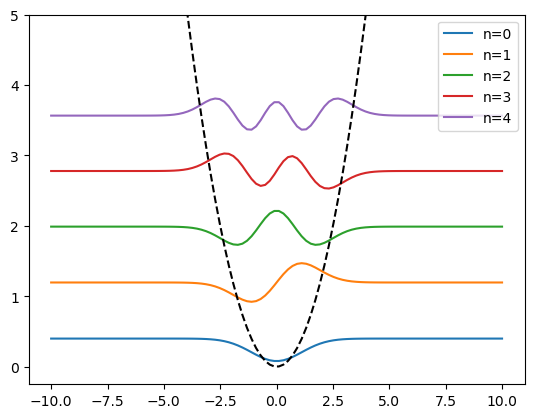

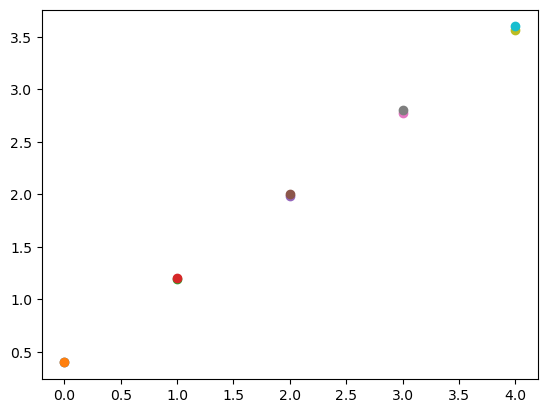

**(e) [REPORT FIGURE] Finite double-Square Well Potential**
- Test your `hamiltonian()` function for a particle in a symmetric double-square well potential defined by:
  $$
  V(x) = 
  \begin{cases} 
  V_0 & \text{if } 0 \le \vert{}x\vert{} < \frac{a}{2} \quad (\text{central barrier}) \\ 
  0 & \text{if } \frac{a}{2} \le \vert{}x\vert{} < \frac{a}{2} + W \quad (\text{potential wells}) \\ 
  V_0 & \text{if } \vert{}x\vert{} \ge \frac{a}{2} + W \quad (\text{outer walls}) 
  \end{cases}$$
  where $a$ is the central barrier width, $W$ is the width of each well, and $V_0$ is the barrier height.
- Choose appropriate values for parameters $V_0$, $a$, and $W$ ($a<W<L$).
- Calculate the eigenvalues and eigenvectors.
- Plot 1: the lowest energy states shifted by their eigenvalues **alongside** $V(x)$. Make sure to illustrate both bound and unbound states. Explain what you see.
- Plot 2: the calculated eigenvalues $E_n$ as a function of $n$. (No closed-form expressions exists for this potential)

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**(f) Optional**

Numerically verify that your computed Hamiltonian matrix $\mathbf{H}$, eigenvector matrix $\mathbf{V}$ (where columns are eigenvectors), and diagonal eigenvalue matrix $\mathbf{D} = \text{diag}(E_0, E_1, \dots, E_{N-1})$ satisfy (up to some precision) the matrix eigenvalue equation:$$\mathbf{H}\mathbf{V} = \mathbf{V}\mathbf{D}$$.

#### Problem code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)